# Steam Graph Analysis with Phi Similarity

This notebook builds a Steam game similarity graph from positive and negative user recommendation patterns.

Edges are created when two games have enough common reviewers and their binary recommendation patterns have a Phi coefficient above the configured threshold. The node id remains `app_id`; game metadata such as `name` and `genres` is exported as node attributes for Gephi labels.

# Dataset Loading

In [1]:
import math
import random
import sys
from collections import defaultdict
from itertools import combinations
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from pandas.api.types import is_bool_dtype, is_numeric_dtype

from config.paths import (
    SAMPLE_GRAPH_OUTPUT_PATH,
    SAMPLE_GRAPH_VISUAL_OUTPUT_PATH,
    STEAM_GAMES_DATASET_PATH,
    STEAM_RECOMMENDATIONS_PATH,
)

PHI_GRAPH_OUTPUT_PATH = (
    SAMPLE_GRAPH_OUTPUT_PATH.parent
    / "steam_game_phi_similarity_sample_1pct.graphml"
)
PHI_GRAPH_VISUAL_OUTPUT_PATH = (
    SAMPLE_GRAPH_VISUAL_OUTPUT_PATH.parent
    / "steam_game_phi_similarity_visual_sample_1pct.graphml"
)

In [2]:
SAMPLE_FRACTION = 0.01
RANDOM_STATE = 42
MIN_COMMON_REVIEWERS = 30
MIN_PHI = 0.20
VISUAL_SAMPLE_SIZE = 300

In [3]:
def normalize_recommendation_flags(
    series: pd.Series,
) -> pd.Series:
    series = series.dropna()

    if is_bool_dtype(series):
        return series.astype(bool)

    if is_numeric_dtype(series):
        return series.astype(int).astype(bool)

    normalized = series.astype(str).str.strip().str.lower()
    bool_mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False,
    }

    unknown_values = sorted(
        set(normalized.dropna()) - set(bool_mapping)
    )

    if unknown_values:
        raise ValueError(
            "Unknown is_recommended values: "
            f"{unknown_values[:10]}"
        )

    return normalized.map(bool_mapping).astype(bool)


def load_recommendations_data() -> pd.DataFrame:
    df_reviews = pd.read_csv(
        STEAM_RECOMMENDATIONS_PATH,
        usecols=["user_id", "app_id", "is_recommended"],
    )

    df_reviews["is_recommended"] = normalize_recommendation_flags(
        df_reviews["is_recommended"]
    )

    return df_reviews


def serialize_graphml_value(value) -> str:
    if value is None:
        return ""

    if isinstance(value, float) and math.isnan(value):
        return ""

    if isinstance(value, (list, tuple, set)):
        return ", ".join(str(item) for item in value)

    return str(value)


def first_existing_column(
    columns: pd.Index,
    candidates: list[str],
) -> str | None:
    columns_by_lower = {
        column.lower(): column
        for column in columns
    }

    for candidate in candidates:
        if candidate.lower() in columns_by_lower:
            return columns_by_lower[candidate.lower()]

    return None


def load_games_metadata() -> dict:
    df_games = pd.read_csv(STEAM_GAMES_DATASET_PATH)

    app_id_column = first_existing_column(
        df_games.columns,
        ["app_id", "id", "steam_appid"],
    )

    if app_id_column is None:
        raise ValueError(
            "games.csv must contain an app id column. Tried: "
            "app_id, id, steam_appid"
        )

    name_column = first_existing_column(
        df_games.columns,
        ["title", "name", "app_name"],
    )
    genres_column = first_existing_column(
        df_games.columns,
        ["genres", "genre", "tags", "categories"],
    )

    metadata = {}

    for row_data in df_games.to_dict(orient="records"):
        app_id = row_data[app_id_column]
        node_metadata = {
            "name": serialize_graphml_value(
                row_data.get(name_column, "")
            ),
            "genres": serialize_graphml_value(
                row_data.get(genres_column, "")
            ),
        }

        metadata[app_id] = node_metadata
        metadata[str(app_id)] = node_metadata

    print(f"Loaded game metadata rows: {len(df_games)}")
    print(f"Game name column: {name_column}")
    print(f"Game genres column: {genres_column}")

    return metadata

In [4]:
df_reviews = load_recommendations_data()
games_metadata = load_games_metadata()

print(f"Recommendation rows: {len(df_reviews)}")
print(f"Unique users: {df_reviews['user_id'].nunique()}")
print(f"Unique games: {df_reviews['app_id'].nunique()}")
print(df_reviews["is_recommended"].value_counts(dropna=False))

df_reviews.head()

Loaded game metadata rows: 50872
Game name column: title
Game genres column: None
Recommendation rows: 41154794
Unique users: 13781059
Unique games: 37610
is_recommended
True     35304398
False     5850396
Name: count, dtype: int64


,app_id,is_recommended,user_id
0,975370,True,51580
1,304390,False,2586
2,1085660,True,253880
3,703080,True,259432
4,526870,True,23869


# Data Preprocessing

The preprocessing keeps both positive and negative recommendations. Duplicate user-game rows are removed so each user contributes at most one binary evaluation per game.

In [5]:
def preprocess_recommendations_data(
    df_reviews: pd.DataFrame,
) -> pd.DataFrame:
    initial_rows = len(df_reviews)

    df_reviews = df_reviews.dropna(
        subset=["user_id", "app_id", "is_recommended"],
    ).copy()

    duplicate_mask = df_reviews.duplicated(
        subset=["user_id", "app_id"],
        keep=False,
    )
    duplicate_rows = int(duplicate_mask.sum())

    conflicting_duplicates = (
        df_reviews.loc[duplicate_mask]
        .groupby(["user_id", "app_id"])["is_recommended"]
        .nunique()
        .gt(1)
        .sum()
    )

    df_reviews = df_reviews.drop_duplicates(
        subset=["user_id", "app_id"],
        keep="first",
    )

    print(f"Rows before preprocessing: {initial_rows}")
    print(f"Rows after preprocessing: {len(df_reviews)}")
    print(f"Duplicate user-game rows removed: {duplicate_rows}")
    print(f"Conflicting duplicate user-game pairs: {conflicting_duplicates}")

    return df_reviews


def sample_reviews_by_users(
    df_reviews: pd.DataFrame,
    sample_fraction: float = SAMPLE_FRACTION,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    sampled_users = (
        df_reviews["user_id"]
        .drop_duplicates()
        .sample(
            frac=sample_fraction,
            random_state=random_state,
        )
    )

    df_sample = df_reviews[
        df_reviews["user_id"].isin(sampled_users)
    ].copy()

    print(f"Sample fraction: {sample_fraction:.2%}")
    print(f"Sample users: {df_sample['user_id'].nunique()}")
    print(f"Sample reviews: {len(df_sample)}")
    print(f"Sample games: {df_sample['app_id'].nunique()}")
    print(df_sample["is_recommended"].value_counts(dropna=False))

    return df_sample


df_reviews = preprocess_recommendations_data(df_reviews)
df_sample = sample_reviews_by_users(df_reviews)

df_sample.head()

Rows before preprocessing: 41154794
Rows after preprocessing: 41154773
Duplicate user-game rows removed: 42
Conflicting duplicate user-game pairs: 5
Sample fraction: 1.00%
Sample users: 137811
Sample reviews: 412028
Sample games: 16756
is_recommended
True     352815
False     59213
Name: count, dtype: int64


,app_id,is_recommended,user_id
75,376210,True,944679
364,1172470,True,1194057
516,238960,True,2947479
565,431960,True,6881911
578,815370,True,7584816


# Phi Similarity Model

For each candidate pair of games A and B, only users who evaluated both games are considered.

| | B positive | B negative |
|---|---:|---:|
| A positive | a | b |
| A negative | c | d |

The Phi coefficient is computed as:

$$\phi = \frac{ad - bc}{\sqrt{(a+b)(a+c)(b+d)(c+d)}}$$

Interpretation: `+1` means strong similarity, `0` means no relationship, and `-1` means strong opposition.

In [6]:
def build_user_reviews_map(
    df_reviews: pd.DataFrame,
) -> dict:
    return (
        df_reviews
        .groupby("user_id")
        .apply(
            lambda group: dict(
                zip(group["app_id"], group["is_recommended"])
            )
        )
        .to_dict()
    )


def build_game_reviews_map(
    df_reviews: pd.DataFrame,
) -> dict:
    game_reviews_map = defaultdict(dict)

    for user_id, app_id, is_recommended in df_reviews[[
        "user_id",
        "app_id",
        "is_recommended",
    ]].itertuples(index=False):
        game_reviews_map[app_id][user_id] = bool(is_recommended)

    return dict(game_reviews_map)


def build_game_reviews_map_from_user_reviews(
    user_reviews_map: dict,
) -> dict:
    game_reviews_map = defaultdict(dict)

    for user_id, reviews in user_reviews_map.items():
        for app_id, is_recommended in reviews.items():
            game_reviews_map[app_id][user_id] = bool(is_recommended)

    return dict(game_reviews_map)


def generate_candidate_pairs(
    df_reviews: pd.DataFrame,
    min_common_reviewers: int,
) -> dict:
    pair_counts = defaultdict(int)

    user_games = (
        df_reviews
        .groupby("user_id")["app_id"]
        .apply(lambda values: sorted(set(values)))
    )

    for games in user_games:
        if len(games) < 2:
            continue

        for game_1, game_2 in combinations(games, 2):
            pair_counts[(game_1, game_2)] += 1

    return {
        pair: common_reviewers
        for pair, common_reviewers in pair_counts.items()
        if common_reviewers >= min_common_reviewers
    }


def compute_contingency_table(
    game_1,
    game_2,
    game_reviews_map: dict,
) -> tuple[int, int, int, int]:
    game_1_reviews = game_reviews_map.get(game_1, {})
    game_2_reviews = game_reviews_map.get(game_2, {})
    common_users = set(game_1_reviews).intersection(game_2_reviews)

    a = b = c = d = 0

    for user_id in common_users:
        game_1_positive = game_1_reviews[user_id]
        game_2_positive = game_2_reviews[user_id]

        if game_1_positive and game_2_positive:
            a += 1
        elif game_1_positive and not game_2_positive:
            b += 1
        elif not game_1_positive and game_2_positive:
            c += 1
        else:
            d += 1

    return a, b, c, d


def compute_phi(
    a: int,
    b: int,
    c: int,
    d: int,
) -> float:
    denominator = math.sqrt(
        (a + b)
        * (a + c)
        * (b + d)
        * (c + d)
    )

    if denominator == 0:
        return 0.0

    return (a * d - b * c) / denominator

In [7]:
synthetic_user_reviews = {
    1: {"A": True, "B": True, "C": False, "D": True},
    2: {"A": False, "B": False, "C": True, "D": True},
    3: {"A": True, "B": True, "C": False, "D": True},
    4: {"A": False, "B": False, "C": True, "D": True},
}
synthetic_game_reviews = build_game_reviews_map_from_user_reviews(
    synthetic_user_reviews
)

assert compute_contingency_table(
    "A",
    "B",
    synthetic_game_reviews,
) == (2, 0, 0, 2)
assert compute_phi(2, 0, 0, 2) == 1.0

assert compute_contingency_table(
    "A",
    "C",
    synthetic_game_reviews,
) == (0, 2, 2, 0)
assert compute_phi(0, 2, 2, 0) == -1.0

assert compute_contingency_table(
    "A",
    "D",
    synthetic_game_reviews,
) == (2, 0, 2, 0)
assert compute_phi(2, 0, 2, 0) == 0.0

print("Phi validation checks passed.")

Phi validation checks passed.


# Graph Construction

In [8]:
def lookup_game_metadata(
    app_id,
    games_metadata: dict | None,
) -> dict:
    if not games_metadata:
        return {"name": "", "genres": ""}

    return games_metadata.get(
        app_id,
        games_metadata.get(
            str(app_id),
            {"name": "", "genres": ""},
        ),
    )


def build_game_similarity_graph_phi(
    df_reviews_sample: pd.DataFrame,
    games_metadata: dict | None = None,
    min_common_reviewers: int = MIN_COMMON_REVIEWERS,
    min_phi: float = MIN_PHI,
) -> tuple[nx.Graph, dict]:
    user_reviews_map = build_user_reviews_map(df_reviews_sample)
    game_reviews_map = build_game_reviews_map(df_reviews_sample)
    candidate_pairs = generate_candidate_pairs(
        df_reviews_sample,
        min_common_reviewers=min_common_reviewers,
    )

    G = nx.Graph()

    for app_id in sorted(df_reviews_sample["app_id"].unique()):
        node_metadata = lookup_game_metadata(app_id, games_metadata)
        G.add_node(
            app_id,
            app_id=serialize_graphml_value(app_id),
            name=node_metadata["name"],
            genres=node_metadata["genres"],
        )

    for (game_1, game_2), common_reviewers in candidate_pairs.items():
        a, b, c, d = compute_contingency_table(
            game_1,
            game_2,
            game_reviews_map,
        )
        phi = compute_phi(a, b, c, d)

        if phi > min_phi:
            G.add_edge(
                game_1,
                game_2,
                weight=float(phi),
                phi=float(phi),
                common_reviewers=int(common_reviewers),
                both_positive=int(a),
                first_positive_second_negative=int(b),
                first_negative_second_positive=int(c),
                both_negative=int(d),
            )

    print(f"Users in review map: {len(user_reviews_map)}")
    print(f"Candidate pairs: {len(candidate_pairs)}")

    return G, candidate_pairs


G, candidate_pairs = build_game_similarity_graph_phi(
    df_sample,
    games_metadata=games_metadata,
    min_common_reviewers=MIN_COMMON_REVIEWERS,
    min_phi=MIN_PHI,
)

print(f"Nodes (games): {G.number_of_nodes()}")
print(f"Edges (Phi similarity): {G.number_of_edges()}")
print(f"Minimum common reviewers: {MIN_COMMON_REVIEWERS}")
print(f"Minimum Phi: {MIN_PHI}")

/tmp/ipykernel_40076/3491321627.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


Users in review map: 137811
Candidate pairs: 2544
Nodes (games): 16756
Edges (Phi similarity): 1141
Minimum common reviewers: 30
Minimum Phi: 0.2


In [9]:
phi_values = [
    edge_data["phi"]
    for _, _, edge_data in G.edges(data=True)
]

if phi_values:
    phi_series = pd.Series(phi_values)
    print(phi_series.describe())

    strongest_edges = sorted(
        G.edges(data=True),
        key=lambda edge: edge[2]["phi"],
        reverse=True,
    )[:10]

    pd.DataFrame([
        {
            "game_1": game_1,
            "game_2": game_2,
            "phi": edge_data["phi"],
            "common_reviewers": edge_data["common_reviewers"],
        }
        for game_1, game_2, edge_data in strongest_edges
    ])
else:
    print("No edges met the configured Phi threshold.")

count    1141.000000
mean        0.389464
std         0.146837
min         0.200020
25%         0.275092
50%         0.358168
75%         0.472170
max         1.000000
dtype: float64


# Initial Analysis

The graph now represents positive correlation between binary review patterns. Degree measures how many other games have similar recommendation patterns above the selected thresholds.

In [10]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
average_degree = (2 * num_edges) / num_nodes if num_nodes else 0

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Average degree: {average_degree:.2f}")

Number of nodes: 16756
Number of edges: 1141
Average degree: 0.14


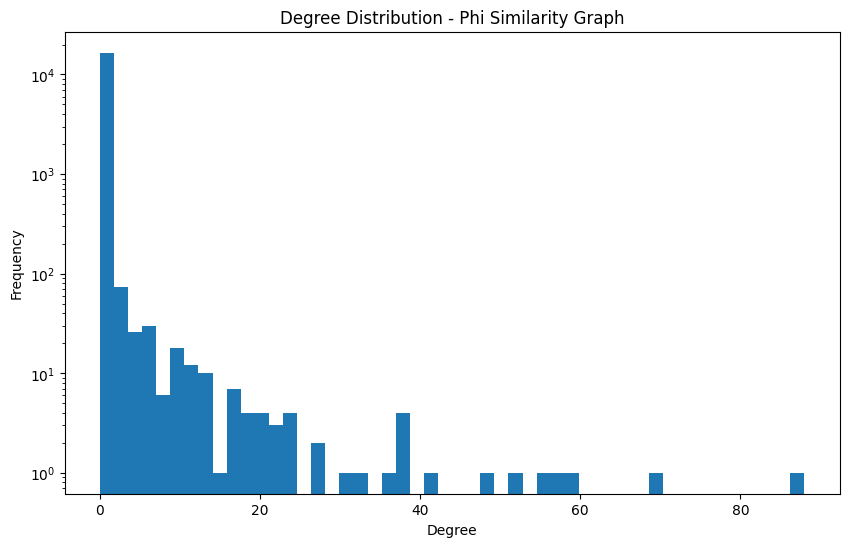

In [11]:
degrees = [degree for _, degree in G.degree()]

plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=50)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution - Phi Similarity Graph")
plt.yscale("log")
plt.show()

In [12]:
num_components = nx.number_connected_components(G) if num_nodes else 0

print(f"Connected components: {num_components}")

Connected components: 16467


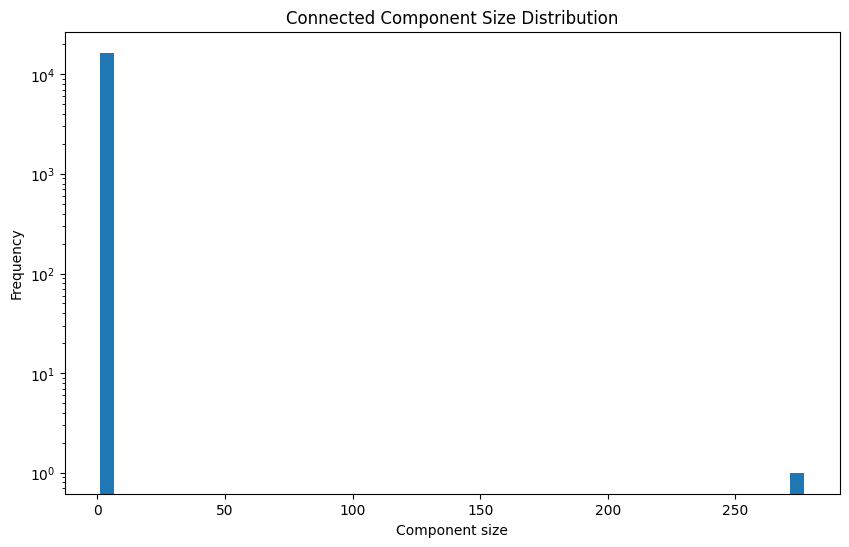

In [13]:
component_sizes = [
    len(component)
    for component in nx.connected_components(G)
]

plt.figure(figsize=(10, 6))
plt.hist(component_sizes, bins=50)
plt.xlabel("Component size")
plt.ylabel("Frequency")
plt.title("Connected Component Size Distribution")
plt.yscale("log")
plt.show()

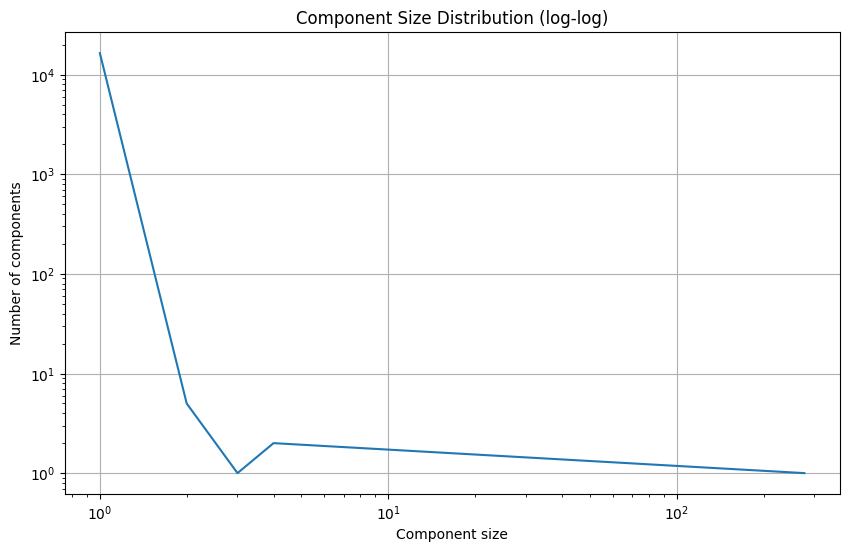

In [14]:
component_size_counts = (
    pd.Series(component_sizes)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))
plt.plot(
    component_size_counts.index,
    component_size_counts.values,
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Component size")
plt.ylabel("Number of components")
plt.title("Component Size Distribution (log-log)")
plt.grid(True)
plt.show()

In [15]:
if num_nodes:
    largest_component = max(
        nx.connected_components(G),
        key=len,
    )
    print(f"Largest component size: {len(largest_component)}")
else:
    largest_component = set()
    print("Largest component size: 0")

Largest component size: 277


# Centrality and Communities

In [17]:
degree_centrality = nx.degree_centrality(G) if num_nodes else {}
pagerank_scores = (
    nx.pagerank(G, weight="weight")
    if num_nodes and num_edges
    else {}
)

betweenness_k = min(100, num_nodes) if num_nodes else None
betweenness_centrality = (
    nx.betweenness_centrality(
        G,
        k=betweenness_k,
        seed=RANDOM_STATE,
    )
    if num_nodes and num_edges
    else {}
)

centrality_summary = pd.DataFrame({
    "degree_centrality": pd.Series(degree_centrality),
    "pagerank": pd.Series(pagerank_scores),
    "betweenness_centrality": pd.Series(betweenness_centrality),
})

centrality_summary.sort_values(
    by="pagerank",
    ascending=False,
).head(20)

,degree_centrality,pagerank,betweenness_centrality
1091500,0.005252,0.002248,0.0
377160,0.004118,0.001523,0.0
440,0.003521,0.001515,0.0
374320,0.003462,0.001375,0.0
292030,0.003283,0.001364,0.0
49520,0.003104,0.001189,0.0
550,0.002925,0.001090,0.0
203160,0.001671,0.000919,0.0
379720,0.002208,0.000836,0.0
1174180,0.002268,0.000812,0.0


In [18]:
try:
    import community as community_louvain

    louvain_partition = (
        community_louvain.best_partition(
            G,
            weight="weight",
            random_state=RANDOM_STATE,
        )
        if num_nodes and num_edges
        else {}
    )

    nx.set_node_attributes(
        G,
        {
            node: int(community_id)
            for node, community_id in louvain_partition.items()
        },
        "louvain_community",
    )

    print(
        "Louvain communities: "
        f"{len(set(louvain_partition.values())) if louvain_partition else 0}"
    )
except ImportError:
    louvain_partition = {}
    print("python-louvain is not installed.")

Louvain communities: 16477


# Export

In [ ]:
def stringify_graph_attributes(
    graph: nx.Graph,
) -> nx.Graph:
    graph_string = graph.copy()

    for _, node_data in graph_string.nodes(data=True):
        for attribute_name, attribute_value in list(node_data.items()):
            node_data[attribute_name] = serialize_graphml_value(attribute_value)

    for _, _, edge_data in graph_string.edges(data=True):
        for attribute_name, attribute_value in list(edge_data.items()):
            edge_data[attribute_name] = serialize_graphml_value(attribute_value)

    return graph_string


PHI_GRAPH_GRAPHI_OUTPUT_PATH = PHI_GRAPH_OUTPUT_PATH.with_name(
    f"{PHI_GRAPH_OUTPUT_PATH.stem}_graphi.graphml"
)

PHI_GRAPH_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

nx.write_graphml(
    G,
    PHI_GRAPH_OUTPUT_PATH,
)

G_graphi = stringify_graph_attributes(G)
nx.write_graphml(
    G_graphi,
    PHI_GRAPH_GRAPHI_OUTPUT_PATH,
)

G_reloaded = nx.read_graphml(PHI_GRAPH_OUTPUT_PATH)
G_graphi_reloaded = nx.read_graphml(PHI_GRAPH_GRAPHI_OUTPUT_PATH)

sample_node_data = next(
    iter(G_reloaded.nodes(data=True)),
    (None, {}),
)[1]
sample_edge_data = next(
    iter(G_reloaded.edges(data=True)),
    (None, None, {}),
)[2]
sample_graphi_edge_data = next(
    iter(G_graphi_reloaded.edges(data=True)),
    (None, None, {}),
)[2]

print(f"Phi graph exported to: {PHI_GRAPH_OUTPUT_PATH}")
print(f"Graphi-compatible Phi graph exported to: {PHI_GRAPH_GRAPHI_OUTPUT_PATH}")
print(f"Reloaded nodes: {G_reloaded.number_of_nodes()}")
print(f"Reloaded edges: {G_reloaded.number_of_edges()}")
print(f"Node attributes available: {sorted(sample_node_data)}")
print(f"Edge attributes available: {sorted(sample_edge_data)}")
print(
    "Graphi edge attribute Python types: "
    f"{ {key: type(value).__name__ for key, value in sample_graphi_edge_data.items()} }"
)

Phi graph exported to: /home/gabrieltrevisan/Documentos/personal/steam-graph-analysis/data/processed/steam_game_phi_similarity_sample_1pct.graphml
Reloaded nodes: 16756
Reloaded edges: 1141
Node attributes available: ['app_id', 'genres', 'louvain_community', 'name']
Edge attributes available: ['both_negative', 'both_positive', 'common_reviewers', 'first_negative_second_positive', 'first_positive_second_negative', 'phi', 'weight']


In [ ]:
if largest_component:
    sample_size = min(
        VISUAL_SAMPLE_SIZE,
        len(largest_component),
    )

    sample_nodes = random.sample(
        list(largest_component),
        sample_size,
    )

    G_visual = G.subgraph(sample_nodes).copy()
else:
    G_visual = G.copy()

PHI_GRAPH_VISUAL_GRAPHI_OUTPUT_PATH = PHI_GRAPH_VISUAL_OUTPUT_PATH.with_name(
    f"{PHI_GRAPH_VISUAL_OUTPUT_PATH.stem}_graphi.graphml"
)

PHI_GRAPH_VISUAL_OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

nx.write_graphml(
    G_visual,
    PHI_GRAPH_VISUAL_OUTPUT_PATH,
)

G_visual_graphi = stringify_graph_attributes(G_visual)
nx.write_graphml(
    G_visual_graphi,
    PHI_GRAPH_VISUAL_GRAPHI_OUTPUT_PATH,
)

print(
    f"Phi visual sample graph exported to: "
    f"{PHI_GRAPH_VISUAL_OUTPUT_PATH}"
)
print(
    f"Graphi-compatible Phi visual sample graph exported to: "
    f"{PHI_GRAPH_VISUAL_GRAPHI_OUTPUT_PATH}"
)
print(f"Sample nodes: {G_visual.number_of_nodes()}")
print(f"Sample edges: {G_visual.number_of_edges()}")

Phi visual sample graph exported to: /home/gabrieltrevisan/Documentos/personal/steam-graph-analysis/data/processed/steam_game_phi_similarity_visual_sample_1pct.graphml
Sample nodes: 277
Sample edges: 1127
